# Lecture 4: Errors and how to spot them

In this lecture we will continue the analysis of the *Stochastic Harvest Process* seen in the previous lecture. We wil try to produce the probability distributions, as done in Lecture 2, to see if they match with the qualitative analysis that we have conducted the last time. We will discorver that there are different kinds of error, and some of them not linked to the numerical, which produce discrepancies with the theoretical results. We will try to understand what is happening in these situations and what is the meaning.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
import random

## Exercise 1: SSPDF of the SHP

In the first part of this lecture, we would like to produce the probability distributions for all the behaviours we have discover the last time. We already know the drill: we will do *trajectory sampling* producing bunches of trajectories with random initial position in $(0,1)$ and we will collect the results after a sufficiently long time. 

### k/a < 1/2

The first situation is when $k/a<1/2$. In this situation the harvest activities are not too much intense and the system is characterized by an upper attractor points that moves towards 1 with the increasing $s$ and the $0$ critical point which perform a flip bifurcation and becomes attractive for $s\approx\sqrt{a-k}$. Visually, we have seen the last time:

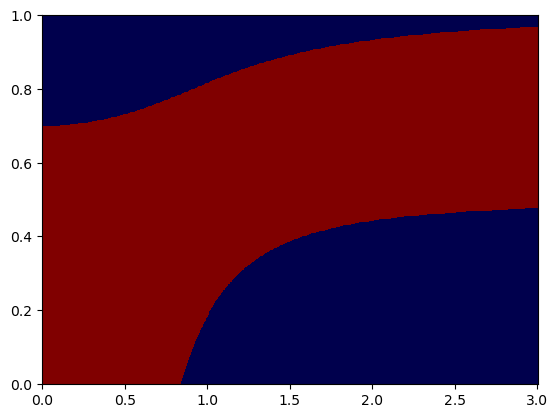

In [2]:
N = 500 #THE NUMBER OF GRID POINTS
a_0 = 1.0
k = 0.3

x = np.linspace(0,1,N)
s = np.linspace(0,3.0,N)

values = np.zeros((N,N),dtype=float)

for i in range(len(x)):
    for j in range(len(s)):
        values[i,j] = a_0*(1-x[i])-k-s[j]*s[j]*(1-x[i])*(1-2*x[i])
        if values[i,j]>=0:
            values[i,j] = 1 #Moving to the right
        else:
            values[i,j] = -1 #Moving to the left

plt.pcolormesh(s,x,values,cmap="seismic") #RED: to the right, BLUE: to the left

*NOTE*: I did not struggle the last time an important fact. When $s\rightarrow +\infty$, we have that the upper point coincide to 1 and the two basins splits in half the domain. The meaning of this is quite simple yet very interesting: a perfectly split basin implies that the trajectories will probabilisticaly converge with simmetry towards the two attractors thus the distribution will be a couple of similar size Dirac's delta. This scenario is a typical case of unknown behaviour: the system can either thrive or be completely destroyed by the noise but it cannot be predicted. This is one of the worst case for a policy maker.

Ok we can try to test for the different value of the noise. But first we need to implement the class copying from the last lecture:

In [3]:
class Harvest(object):

    #CONSTRUCTOR:
    def __init__(self,a: float,k: float,s: float)->None:
        #First let's check the inputs
        if(a<0 or k<0 or s<0):
            raise RuntimeError("The system parameters must be non-negative.")

        self._a = a
        self._k = k
        self._s = s
        return

    #This function is used to change the value of the params between a iteration and another
    def setParam(self,a: float,k: float,s: float)->None:
        '''
        This function recieve new values for the parameters (a,k,s)
        and, after some checks, use them as new params of the Harvest Process.
        '''
        if(a<0 or k<0 or s<0):
            raise RuntimeError("The system parameters must be non-negative.")

        self._a = a
        self._k = k
        self._s = s
        return

    #This function will be used to evolve the deterministic part of the field
    #using Runge-Kutta4
    def __RK4(self,t_n: float,y_n: float,h: float)->float: 
        '''
        Given a point in the trajectory, the time instant and the step lenght,
        this method will compute the variation for y using the RK4 for the 
        deterministic part of the PLS
        '''

        f = lambda x: self._a*x*(1-x)-self._k*x
        
        k_1 = f(y_n)
        k_2 = f(y_n+h*k_1/2)
        k_3 = f(y_n+h*k_2/2)
        k_4 = f(y_n+h*k_3)

        return h*(k_1+2*k_2+2*k_3+k_4)/6
        
    #This function will produce a realization/trajectory for the system
    #using the Milstein discretization.
    def computeTraj(self,n_step: int,h: float,x0: float)->np.array:
        '''
        Given the number of step, the step length and the initial condition,
        this function will produce a trajectory using the Milstein method.
        '''

        #1. Perform some check of the arguments:
        if(n_step<0):
            raise RuntimeError("The number of step must be non-negative.")
        if(h<=0):
            raise RuntimeError("Step size must be positive.")
        if(x0<0):
            raise RuntimeError("The initial size of the population must be non negative.")

        #2. Now we can set the output and start simulate
        traj = np.zeros(n_step+1,dtype=float)
        traj[0] = x0

        for i in range(1,n_step+1):
            traj[i] = traj[i-1]+self.__RK4(i*h,traj[i-1],h) #DETERMINISTIC PART
            eps = random.gauss(0,1)
            traj[i] += self._s*traj[i-1]*(1-traj[i-1])*np.sqrt(h)*eps #FIRST STOCHASTIC TERM
            traj[i] += 0.5*(self._s*traj[i-1]*(1-traj[i-1]))*(self._s*(1-2*traj[i-1]))*h*(eps*eps-1)

        return traj

Now we can try to produce the probability distributions for a noise below the bifurcation. As before, we will fix $a=1.0$ for all the next simulations.

In [4]:
omega = [0.0,1.0]
Nbins = 150
Nsim = 10000
m = (omega[1]-omega[0])/Nbins
system = Harvest(1.0,0.25,0.5) #a=1, k=0.25, s=0.5

bins = np.zeros(Nbins,dtype=float)

for _ in range(Nsim):
    p = system.computeTraj(500,0.1,random.uniform(omega[0],omega[1]))[-1]
    for i in range(Nbins):
        if p < (m*(i+1)+omega[0]):
            bins[i] += 1.0
            break

bins = bins/(Nsim*m)

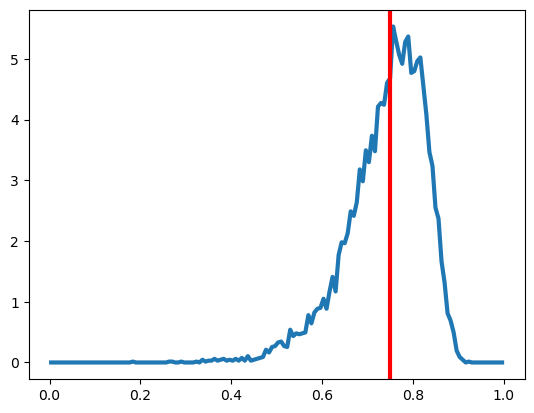

In [5]:
x = np.zeros(Nbins,dtype=float)
for i in range(Nbins):
    x[i] = (m*(i+1/2)+omega[0])

plt.plot(x,bins,lw=3)
plt.axvline(0.75,color='r',lw=3)

Perfect, the system is attracted towards the upper point and, as one can see, the attractor point is moving upward. We can now try what happens after the bifurcation so when $s>\sqrt{a-k}$ (we will take $s=0.95$)

In [6]:
omega = [0.0,1.0]
Nbins = 150
Nsim = 10000
m = (omega[1]-omega[0])/Nbins
system = Harvest(1.0,0.25,1.1) #a=1, k=0.25, s=1.1

bins = np.zeros(Nbins,dtype=float)

for _ in range(Nsim):
    p = system.computeTraj(300,0.1,random.uniform(omega[0],omega[1]))[-1]
    for i in range(Nbins):
        if p < (m*(i+1)+omega[0]):
            bins[i] += 1.0
            break

bins = bins/(Nsim*m)

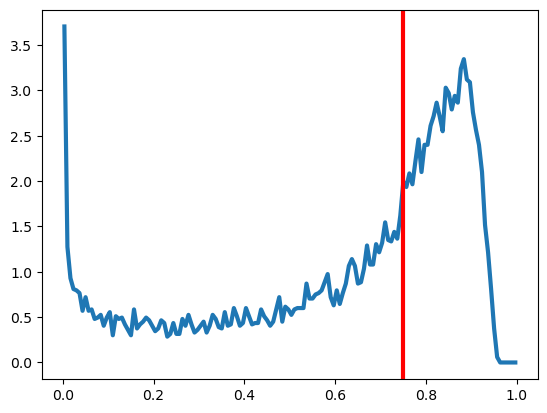

In [7]:
x = np.zeros(Nbins,dtype=float)
for i in range(Nbins):
    x[i] = (m*(i+1/2)+omega[0])

plt.plot(x,bins,lw=3)
plt.axvline(0.75,color='r',lw=3)

Here we can perfectly appreciate the two attractors and the basin between them. For this value of $k/a$ there are no other behaviour thus we can move to the next situation.

## 1/2 < k/a < 2/3 

Here we have this already seen situation:

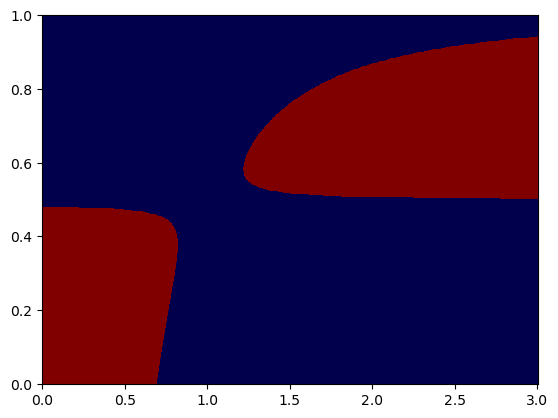

In [8]:
N = 500 #THE NUMBER OF GRID POINTS
a_0 = 1.0
k = 0.52

x = np.linspace(0,1,N)
s = np.linspace(0,3.0,N)

values = np.zeros((N,N),dtype=float)

for i in range(len(x)):
    for j in range(len(s)):
        values[i,j] = a_0*(1-x[i])-k-s[j]*s[j]*(1-x[i])*(1-2*x[i])
        if values[i,j]>=0:
            values[i,j] = 1 #Moving to the right
        else:
            values[i,j] = -1 #Moving to the left

plt.pcolormesh(s,x,values,cmap="seismic") #RED: to the right, BLUE: to the left

Thus, we have some interesting new cases. For around $s=0.75$ we should be in the region between fork bifurcation and the fusion of the two critical point. For $s=1.0$ we should be in a 0 only attractive situation and for $s=2.5$ we should be able to see the two attractors. Let's start with the first:

In [9]:
omega = [0.0,1.0]
Nbins = 150
Nsim = 10000
m = (omega[1]-omega[0])/Nbins
system = Harvest(1.0,0.52,0.75) #a=1, k=0.52, s = 0.75

bins = np.zeros(Nbins,dtype=float)

for _ in range(Nsim):
    p = system.computeTraj(500,0.1,random.uniform(omega[0],omega[1]))[-1]
    for i in range(Nbins):
        if p < (m*(i+1)+omega[0]):
            bins[i] += 1.0
            break

bins = bins/(Nsim*m)

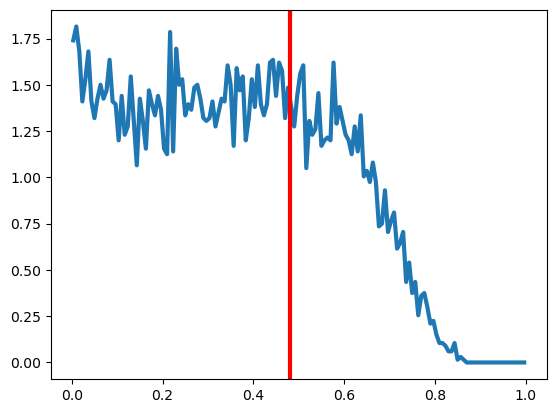

In [10]:
x = np.zeros(Nbins,dtype=float)
for i in range(Nbins):
    x[i] = (m*(i+1/2)+omega[0])

plt.plot(x,bins,lw=3)
plt.axvline(0.48,color='r',lw=3)

As we can notice, $x=0$ is clearly 0 and it is a bit taller probably due to his suppressive properties. In the middle the repulsor point is not so easy to spot: this happens quite often because, even if the distribution as a minimum in it, the method does not tell us how actually deep is the basin. We can interpret this situation as follow: we do not now exactly the abount biomass but will be most probably below the $50\%$ of the carry capacity of the forest with a preference towards 0. Let's see what happens when $s=1.0$.

In [11]:
omega = [0.0,1.0]
Nbins = 150
Nsim = 10000
m = (omega[1]-omega[0])/Nbins
system = Harvest(1.0,0.52,1) #a=1, k=0.52, s = 1

bins = np.zeros(Nbins,dtype=float)

for _ in range(Nsim):
    p = system.computeTraj(500,0.1,random.uniform(omega[0],omega[1]))[-1]
    for i in range(Nbins):
        if p < (m*(i+1)+omega[0]):
            bins[i] += 1.0
            break

bins = bins/(Nsim*m)

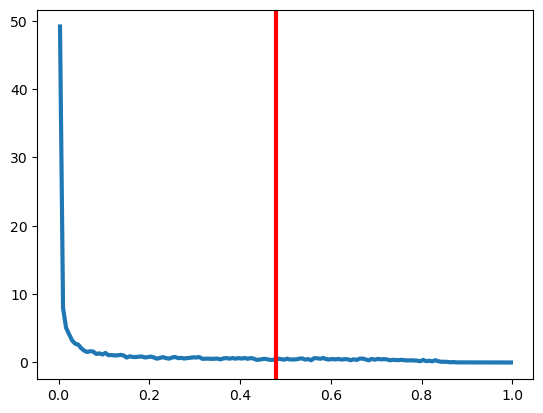

In [12]:
x = np.zeros(Nbins,dtype=float)
for i in range(Nbins):
    x[i] = (m*(i+1/2)+omega[0])

plt.plot(x,bins,lw=3)
plt.axvline(0.48,color='r',lw=3)

The behaviour is evident: it is completely centered towards 0 exactyle as expected! Now we have only the $s=2.5$ case. If we keep the same stpe length we will not be able to obtain decent results because the time step is too wide for be compatible with the smoothness of the stochastic component.

In [13]:
omega = [0.0,1.0]
Nbins = 150
Nsim = 10000
m = (omega[1]-omega[0])/Nbins
system = Harvest(1.0,0.52,2.5) #a=1, k=0.52, s = 2.5

bins = np.zeros(Nbins,dtype=float)

for _ in range(Nsim):
    p = system.computeTraj(500,0.01,random.uniform(omega[0],omega[1]))[-1]
    for i in range(Nbins):
        if p < (m*(i+1)+omega[0]):
            bins[i] += 1.0
            break

bins = bins/(Nsim*m)

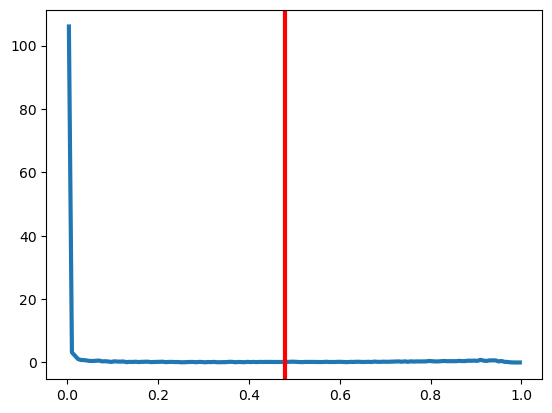

In [14]:
x = np.zeros(Nbins,dtype=float)
for i in range(Nbins):
    x[i] = (m*(i+1/2)+omega[0])

plt.plot(x,bins,lw=3)
plt.axvline(0.48,color='r',lw=3)

Wait... why? We have this behavior? There should be an attractor point near $1$ but there is not. There is a possibility: the point is an attractor but is very low in value thus is not visible and cannot be estimated using simulations because the number is too few. This is partially true but it is not all the story. There are often some situation in which the value of an attractor is decent but it does not appear. Certainly, if we use tons of simulations it will appear eventually but the strange things is that if we increase the number of steps of the trajectory the attractor will disappear after a certain point. To make the behaviour appear you need to cut the trajectories before. BUT which is the real steady state? Are we making some sort of errors?

Answering to this questions is incredibly difficult. The first thing to know is that this problems is a sort of *meta-error*. It does not depends from the particular characteristics of the numerical method we are opting to use but to the nature of the problem itself we are trying to solve. Therefore, even if we are making some errors, in every scenario this is not due to our computational capacity or the cumulative error of the method; it is something more deep and can even raise some phylosofical yet technical questions. Moreover, if you want to try, also for $k/a<1/2$ this phenomena appear if the s value is sufficiently big ($s\approx 1.5$ shows already this problem).

## Exercise 2: Telegraphic Noise and Error

Our objective is to understand better the nature of the error and its source. We already know something about *meta-errors* and the fact that methods have a cumulative error in the last point that depends by the step and the regularity of the considered field. Focusing on the second kind of error, the only one where we can actually interven efficiently, there is a simple question: how I can recognize it? Which are the sympthoms of the error?

This question is very complex and unluckly there is no fixed answer. The worst part of working with this kind of things is that it is usually very difficult to realize that the parameters of the simulation (number of steps, length, ...) are not ideal or in some case the numerical method does not fit the situation. In some lucky cases is very evident with completely different behaviour but in other cases the differences are very difficult to spot or appears only with some configurations of parameters. 

Due to this aspects, it is actually not trivial to find an unique way to study the noise and to prevent it. One of the easiest case is when the noise is able to produce for certain probability distribution significat differences on the behaviour or at least in the critical point position. To do this more easily, we will introduce a new system based on an new kind of noise!

**PROBLEM**: let's consider a very simple system characterize by a generic noise $\eta(t)$:

$$
\frac{dx}{dt}=-\gamma x+\omega\eta(t)
$$

with $\gamma,\omega>0$. In particular we will consider as noise the so-called **telegraphic noise**. This noise is a bounded noise and it is a variation known as *functional usage* of a much more common noise known as **Dichotomous Markov Noise**. The telegraphic noise is defined as:

$$
\eta(t)=
\begin{cases}
A: 1\\
B: -1
\end{cases}
$$

Having this noise is like having a variable for the system which can have only one of two possible status (namely A and B) and we have a probability $P_A$ to transit $A\rightarrow B$ and a probability $1-P_A$ to transit $B\rightarrow A$ in every instant. Therefore at every instant we will have to check if the transition occurs and adapt the system accordingly. Let's implement this class:

In [15]:
class Telegraphic(object):

    #CONSTRUCTOR:
    def __init__(self,g: float,o: float,PT: float)->None:
        #First let's check the inputs
        if(g<0 or o<0):
            raise RuntimeError("The system parameters must be non-negative.")
        if(PT<0 or PT>1):
            raise RuntimeError("The probability transition must be a probability.") 

        self._gamma = g
        self._omega = o
        self._PT = PT
        
        self._state = 1 #We set the initial state as 1 as a placeholder
        return

    #This is used at the beginning of each simulation.
    def __sort_initial_state(self)->None:
        '''
        This function will sort the initial state using the probability
        of transition passed during construction.
        '''
        if(random.uniform(0,1)<=self._PT):
            self._state = -1
        else:
            self._state = 1

    #This is used to sort the new state at every time step.
    def __compute_new_state(self,h:float)->None:
        '''
        Given the time step, PT is based on the time unit, this
        function will compute the new state for the trajectory.
        '''
        if(self._state==1):
            if(random.uniform(0,1)<=self._PT*h):
                self._state = -1
        else:
            if(random.uniform(0,1)<=(1.0-self._PT)*h):
                self._state = 1

    #This function will be used to evolve the deterministic part of the field
    #using Runge-Kutta4
    def __RK4(self,t_n: float,y_n: float,h: float)->float: 
        '''
        Given a point in the trajectory, the time instant and the step lenght,
        this method will compute the variation for y using the RK4 for the 
        deterministic part of the PLS
        '''

        f = lambda x: -self._gamma*x
        
        k_1 = f(y_n)
        k_2 = f(y_n+h*k_1/2)
        k_3 = f(y_n+h*k_2/2)
        k_4 = f(y_n+h*k_3)

        return h*(k_1+2*k_2+2*k_3+k_4)/6
        
    #This function will produce a realization/trajectory for the system
    #using the Milstein discretization.
    def computeTraj(self,n_step: int,h: float,x0: float)->np.array:
        '''
        Given the number of step, the step length and the initial condition,
        this function will produce a trajectory using the Milstein method.
        '''

        #1. Perform some check of the arguments:
        if(n_step<0):
            raise RuntimeError("The number of step must be non-negative.")
        if(h<=0):
            raise RuntimeError("Step size must be positive.")

        #2. Now we can set the output and the initial state and start simulate
        traj = np.zeros(n_step+1,dtype=float)
        traj[0] = x0
        
        self.__sort_initial_state() #SET INITIAL STATE
        
        for i in range(1,n_step+1):
            self.__compute_new_state(h)
            traj[i] = traj[i-1]+self.__RK4(i*h,traj[i-1],h) #DETERMINISTIC PART
            traj[i] += self._omega*self._state*h

        return traj

Where I have supposed that the initial state cannot be pass but it is randomly assigned. We can now try to simulate it. Let's pose for simplicity $\gamma=\omega=1$ and $P_T=0.5$.

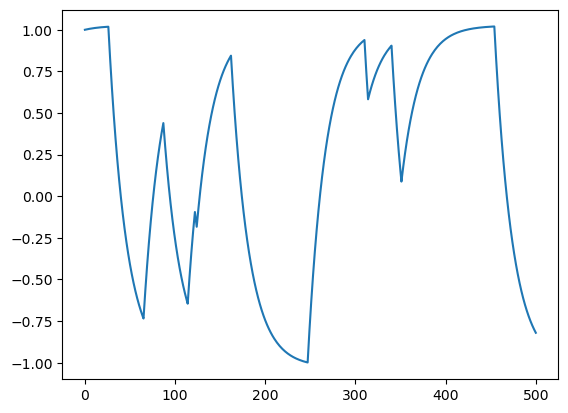

In [16]:
system = Telegraphic(1.0,1.0,0.5)

t = system.computeTraj(500,0.05,1.0)
plt.plot(t)

Now, doing some very simple qualitative analysis we have that for the state A the system should converge around $\omega/\gamma$ and for the state B to the symmetric point $-\omega/\gamma$. If we consider the average probability for $P_A=0.5$, the system should stay most of the time around 0 but the above simulation shows that this is probably not true. The average point could be a good approximation usually only for very weak dynamics in comparison with the dynamics of changing state. However we can imagine that for growing $P_A$ the system will stay more around the below value while for lower values will stay more around the upper one.

We can try to compute the probability distribution:

In [17]:
omega = [-1.0,1.0]
Nbins = 150
Nsim = 1000 
m = (omega[1]-omega[0])/Nbins
system = Telegraphic(1.0,1.0,0.5)

bins = np.zeros(Nbins,dtype=float)

for _ in range(Nsim):
    p = system.computeTraj(500,0.05,random.uniform(omega[0],omega[1]))[-1]
    for i in range(Nbins):
        if p <= (m*(i+1)+omega[0]):
            bins[i] += 1.0
            break

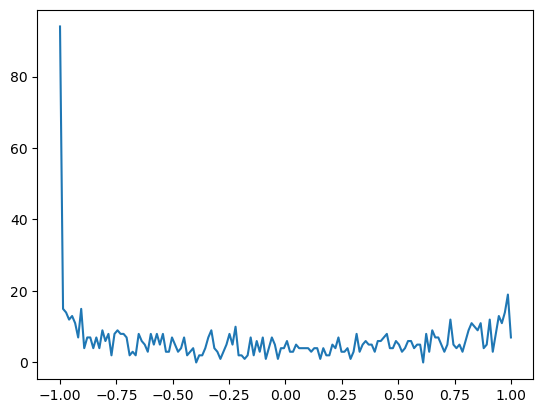

In [18]:
x = np.linspace(omega[0],omega[1],Nbins)

plt.xlim(omega[0]-0.1,omega[1]+0.1)
plt.plot(x,bins)

Something strange is starting to happen. The two critical points should be equal in probabilities. Obviously we do not expect to have equal peaks but there there is a clear difference between the two which looks a lot like a possible error. Let's continue for now because we need to understand better.

Let's try more extreme parameters.

In [19]:
omega = [-0.3,0.3]
Nbins = 150
Nsim = 1000 
m = (omega[1]-omega[0])/Nbins
system = Telegraphic(4.0,1.0,0.1) #Thus omega/gamma = 0.25 and the upper state is more common than the lower (PT=0.1) 


bins = np.zeros(Nbins,dtype=float)

for _ in range(Nsim):
    p = system.computeTraj(500,0.05,random.uniform(omega[0],omega[1]))[-1]
    for i in range(Nbins):
        if p <= (m*(i+1)+omega[0]):
            bins[i] += 1.0
            break

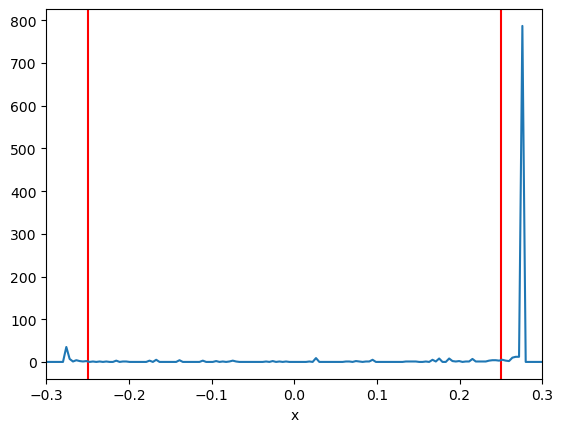

In [20]:
x = np.linspace(omega[0],omega[1],Nbins)

plt.xlabel("x")
plt.axvline(x = 0.25, color = 'r')
plt.axvline(x = -0.25, color = 'r')
plt.xlim(omega[0],omega[1])
plt.plot(x,bins)

There are theoretically no other NIT for our problem. If we look more we will also been able to see that the distribution is almost immune to the ratio between $\omega$ and $\gamma$ other than the position of the attractor point. However looking more deeply to our results if we try to move away from this ideal situation we can observe that the attractors are not precisely placed on the $\omega/\gamma$ value but instead they seem to be slighlty demished. Looking back to the equation this shift of the attractors is unconcivable also because the shift is upward. 

Playing a bit with all the parameters including the time lenght and the number of simulation we can find that for longer simulation, with fixed steps, this shift increase and for fewer number of steps this problem also became larger. So we can start to make a guess: this is a typical cumulative error problem!

So these are usually valid method to spot cumulative error problems: most of the time if there is an error that is influencing the system using different length or number of step for the simulation produce noticeable differences in the results. This results usually diverge from the theoretical value for smaller number of time steps or increasings in the step size. On the other hand, the meta error usually does not depend too much from the step size but only from the length. 

Can we fix this problem? Being a cumultive error this comes from the numerical method. Most probably the source of our error is that the noise is integrated via au Euler method but this is not actually a noise inside the step: it is purely deterministic. Thus we can put it in the RK4 method!

In [21]:
class Telegraphic(object):

    #CONSTRUCTOR:
    def __init__(self,g: float,o: float,PT: float)->None:
        #First let's check the inputs
        if(g<0 or o<0):
            raise RuntimeError("The system parameters must be non-negative.")
        if(PT<0 or PT>1):
            raise RuntimeError("The probability transition must be a probability.") 

        self._gamma = g
        self._omega = o
        self._PT = PT
        
        self._state = 1 #We set the initial state as 1 as a placeholder
        return

    #This is used at the beginning of each simulation.
    def __sort_initial_state(self)->None:
        '''
        This function will sort the initial state using the probability
        of transition passed during construction.
        '''
        if(random.uniform(0,1)<=self._PT):
            self._state = -1
        else:
            self._state = 1

    #This is used to sort the new state at every time step.
    def __compute_new_state(self,h:float)->None:
        '''
        Given the time step, PT is based on the time unit, this
        function will compute the new state for the trajectory.
        '''
        if(self._state==1):
            if(random.uniform(0,1)<=self._PT*h):
                self._state = -1
        else:
            if(random.uniform(0,1)<=(1.0-self._PT)*h):
                self._state = 1

    #This function will be used to evolve the deterministic part of the field
    #using Runge-Kutta4
    def __RK4(self,t_n: float,y_n: float,h: float)->float: 
        '''
        Given a point in the trajectory, the time instant and the step lenght,
        this method will compute the variation for y using the RK4 for the 
        deterministic part of the PLS
        '''

        f = lambda x: -self._gamma*x + self._omega*self._state
        
        k_1 = f(y_n)
        k_2 = f(y_n+h*k_1/2)
        k_3 = f(y_n+h*k_2/2)
        k_4 = f(y_n+h*k_3)

        return h*(k_1+2*k_2+2*k_3+k_4)/6
        
    #This function will produce a realization/trajectory for the system
    #using the Milstein discretization.
    def computeTraj(self,n_step: int,h: float,x0: float)->np.array:
        '''
        Given the number of step, the step length and the initial condition,
        this function will produce a trajectory using the Milstein method.
        '''

        #1. Perform some check of the arguments:
        if(n_step<0):
            raise RuntimeError("The number of step must be non-negative.")
        if(h<=0):
            raise RuntimeError("Step size must be positive.")

        #2. Now we can set the output and the initial state and start simulate
        traj = np.zeros(n_step+1,dtype=float)
        traj[0] = x0
        
        self.__sort_initial_state() #SET INITIAL STATE
        
        for i in range(1,n_step+1):
            self.__compute_new_state(h)
            traj[i] = traj[i-1]+self.__RK4(i*h,traj[i-1],h) #DETERMINISTIC PART
            #NOW THE NOISE IS INSIDE THE PREVIOUS LINE

        return traj

In [22]:
omega = [-0.3,0.3]
Nbins = 150
Nsim = 1000 
m = (omega[1]-omega[0])/Nbins
system = Telegraphic(4.0,1.0,0.1) #Thus omega/gamma = 0.25 and the upper state is more common than the lower (PT=0.1) 


bins = np.zeros(Nbins,dtype=float)

for _ in range(Nsim):
    p = system.computeTraj(500,0.05,random.uniform(omega[0],omega[1]))[-1]
    for i in range(Nbins):
        if p <= (m*(i+1)+omega[0]):
            bins[i] += 1.0
            break

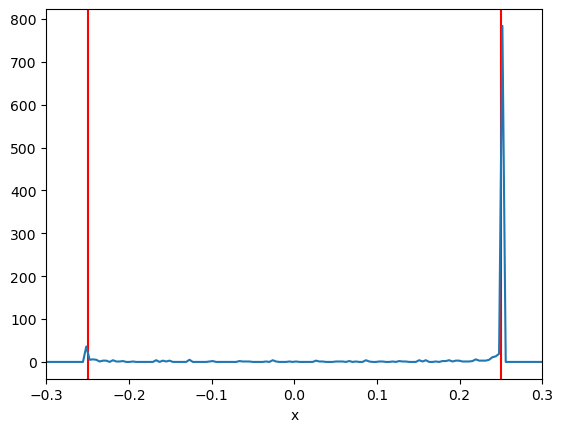

In [23]:
x = np.linspace(omega[0],omega[1],Nbins)

plt.xlabel("x")
plt.axvline(x = 0.25, color = 'r')
plt.axvline(x = -0.25, color = 'r')
plt.xlim(omega[0],omega[1])
plt.plot(x,bins)

Much better! Let's see if also the previous situation now works better!

In [24]:
omega = [-1.0,1.0]
Nbins = 150
Nsim = 1000 
m = (omega[1]-omega[0])/Nbins
system = Telegraphic(1.0,1.0,0.5)

bins = np.zeros(Nbins,dtype=float)

for _ in range(Nsim):
    p = system.computeTraj(500,0.05,random.uniform(omega[0],omega[1]))[-1]
    for i in range(Nbins):
        if p <= (m*(i+1)+omega[0]):
            bins[i] += 1.0
            break

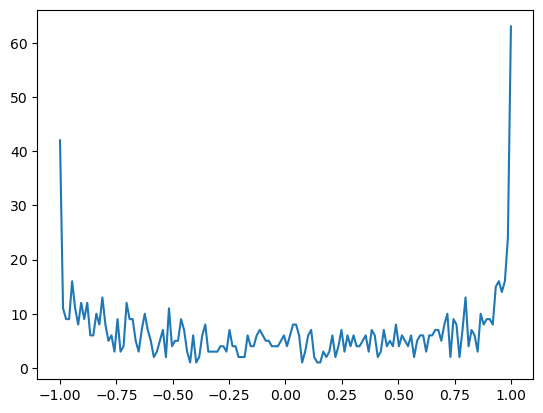

In [25]:
x = np.linspace(omega[0],omega[1],Nbins)

plt.xlim(omega[0]-0.1,omega[1]+0.1)
plt.plot(x,bins)

Finally also here the two peaks now have comparable values in probability! As you have seen, we were able eventually to correct our error but there is a key problem: if there are tons of scenario and we cannot check manually how we can spot if there is an error?

## Exercise 3: How to compute the divergence

The idea is to use some sort of "correct reference" to confront it with our SSPDF obtained via simulations. One possibility is to use the Fokker-Plank equation. In the best case scenario it is actually solvable analytically, while, in the worst case scenario, we should be able to use some kind of bidirectional Finite Difference method to obtain the numerical solution from the differential equation. This has only one big limitation which is the integrability request on the Fokker-Plank: often the solution of the FP covers only the intermediate behaviour of a system while the most extreme are not integrable however this is not too much of a problem.

In fact the integrability most of the time is broken due to some kind of divergences inside the domain or at the border. In this situation a possible difference between two distribution tends to explode naturally. Why? Try to think about it!

Found a suitable reference we have to express how much different are the two methods. For this we need to find or create some kind of measure...

But first thing first, let's setup a system to test our error finding methods!

### Back to the Harvest process...

To do this let's go back to the Harvest process. I recall that our stochastic version of this process is defined by the Ito's form:

$$
dx = \left(ax(1-x)-kx\right)dt+sx(1-x)dW
$$

Until now we haven't look at the steady-state Fokker-Plank equation associated to this system. Maybe it is time...

$$
\left(ax(1-x)-kx\right)P_s(x)=\frac{1}{2}\frac{\partial}{\partial x}\left(s^2x^2(1-x)^2P_s(x)\right)
$$

It is actually not so difficult in practice but quite long. If one applies the derivative and then write in the form of $P_s'(x)=[...]$, it is possible to separate the variable. On the right hand there are three terms but each member of the numerators can be decoupled in a bunch of addends with $x$ only at the denominator. Then one can simply apply the integral to each member and then wrap up. The solution is:

$$
P_s(x)=A(1-x)^{-\frac{2(a_0+s^2-k)}{s^2}}x^{-\frac{2(-a_0+s^2+k)}{s^2}}e^{\frac{2k}{s^2(x-1)}}
$$

Where $A$ is the normalization constant. However this cannot be found analytically without using Gamma functions and similar objects. Nonetheless, this is not a problem: we already have seen how to find it numerically! We will start to test the error from the parameter configuration $(a,k,s)=(1,0.25,0.5)$ used at the beginning.

In [26]:
a = 1.0
k = 0.25
s = 0.5

P_s = lambda x: (1-x)**(-(2*(a+s**2-k))/s**2)*x**(-(2*(-a+s**2+k))/s**2)*np.exp(2*k/(s**2*(x-1)))

#Now lets make the grid and the step:
x = np.linspace(0,1,1000)
delta = x[1]-x[0] #in this case is constant

A = 0.0
for i in range(len(x)-2): #The last point is 1 and it is not defined the solution here
    A += delta*(P_s(x[i])+P_s(x[i+1]))/2

A = 1/A

print(A)

0.7297833184129039


Now we can produce our trajectory sampling and check if the simulations produce the same results predicted by the Fokker-Plank

In [27]:
omega = [0.0,1.0]
Nbins = 150
Nsim = 10000
m = (omega[1]-omega[0])/Nbins
system = Harvest(1.0,0.25,0.5) #a=1, k=0.25, s=0.5

bins = np.zeros(Nbins,dtype=float)

for _ in range(Nsim):
    p = system.computeTraj(500,0.1,random.uniform(omega[0],omega[1]))[-1]
    for i in range(Nbins):
        if p < (m*(i+1)+omega[0]):
            bins[i] += 1.0
            break

bins = bins/(Nsim*m)

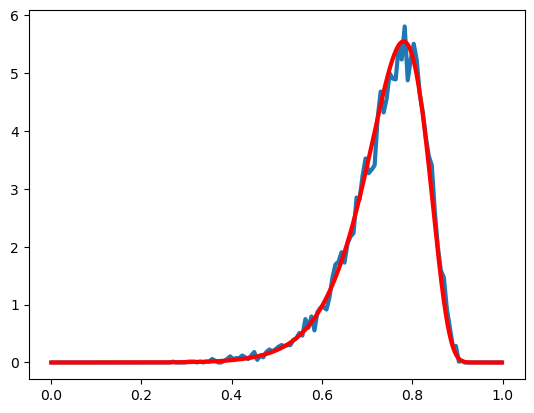

In [28]:
dist = P_s(x[:-1])*A

x_s = np.zeros(Nbins,dtype=float)
for i in range(Nbins):
    x_s[i] = (m*(i+1/2)+omega[0])

plt.plot(x_s,bins,lw=3)
plt.plot(x[:-1],dist,lw=3,color='r')

Kanpeki! The SSPDF obtain from the simulations mimicks perfectly the values of the solution obtained from the Fokken-Plank.

### Kullback-Leiber Distance

Ok now we need to compute the distance between the two distributions. There are a lot of ways (we will see other in the future) but in this case we will use the **Kullback-Leiber distance or divergence**. This is a quantification of the distance between two distributions. It has not an absolut meaning beside from the 0 case in which we have no error so it can be used only under a comparison point of view. In our case having distributions such the one above where the two almost coincide give us some paragons.  

The Kullback-Leiber divergence given two distributions $P(x)$ and $Q(x)$ is

$$
D_{KL}(P||Q)=\sum_i P(i)\log_2\left(\frac{P(i)}{Q(i)}\right)
$$

Some important observations:

- Firstly, the KL is not a symmetric distance so doing $D_{KL}(Q||P)$ will produce different results. For this reason is important to keep the role of the two distributions.
- Secondly, the $Q(x)$ has a further hypothesis which is that $Q(x)>0$ $\forall x$. So 0 values are not admitted for this distribution.

For this reason, in our case the only possible solution will be to use as $P(x)$ the bins and as $Q(x)$ the analytical one.

However, using the solution of the FP as $Q(x)$ can lead to some problems:

In [29]:
print(A*P_s(x[:-1]))

[0.00000000e+000 9.97590400e-014 1.60576960e-012 8.17826164e-012
 2.60034173e-011 6.38684981e-011 1.33238478e-010 2.48334208e-010
 4.26212139e-010 6.86845629e-010 1.05320786e-009 1.55135639e-009
 2.21051941e-009 3.06318359e-009 4.14518381e-009 5.49579449e-009
 7.15782281e-009 9.17770368e-009 1.16055966e-008 1.44954843e-008
 1.79052734e-008 2.18968971e-008 2.65364195e-008 3.18941422e-008
 3.80447129e-008 4.50672359e-008 5.30453853e-008 6.20675192e-008
 7.22267973e-008 8.36213000e-008 9.63541499e-008 1.10533636e-007
 1.26273339e-007 1.43692260e-007 1.62914953e-007 1.84071657e-007
 2.07298429e-007 2.32737290e-007 2.60536357e-007 2.90849993e-007
 3.23838951e-007 3.59670521e-007 3.98518685e-007 4.40564270e-007
 4.85995106e-007 5.35006183e-007 5.87799818e-007 6.44585820e-007
 7.05581658e-007 7.71012634e-007 8.41112057e-007 9.16121424e-007
 9.96290600e-007 1.08187800e-006 1.17315079e-006 1.27038506e-006
 1.37386602e-006 1.48388823e-006 1.60075577e-006 1.72478244e-006
 1.85629200e-006 1.995618

As we can notice there are still some values which are 0 due to the finite number of cyphers that the float can store. We can opt for two possible solutions:

- Do a correction to all of those points transforming them in some values near 0
- Do not consider all the case in which the analytical solution is 0.

Both of the solutions have some pros and cons. However we can try to think a bit upon the second solution which seems the easier under the coding POV. We can reinforce this choice doing some considerations:

- Given the fact that we will stay in the parametrical condition for which our analytical distribution is valid, we have that the behaviours of the two should not be too much different so we can expect to have the same critical points
- If we have not the same critical points, we can expect that the attractiveness of a critical point will be overevaluated in the simulation and for this reason another one disappear. So the number of the critical points of the simulations should be lesser or equal than the number of critical points of the analytical solution.

For these reasons we can imagine that in the areas where the analytical solutions tends to 0 (the antimodes) we should have that the simulations should have almost 0 values and all the problems on the error should appear on the attractive critical points (both value differences and the absence of an attractor point for the simulations) and in their neighborhood. So we can opt for the second solution and do not count the 0 values situations for the analytical distribution. Moreover despite some pathological cases, with a sufficient number of points the impact of a single one will be on average neglibible.

So let's prepare a method to compute this distance. We have also to remember to adjust the case in which $P[i]=0$ manually to have no problem with the computations. Actually, we can join the case of $P[i]=0$ and $Q[i]=0$ because in the first case we have to manually sum 0 and in the second we need to skip that element on the sum but, at the end, the contribution is the same.

In [30]:
def kullback_leiber(P: np.array,Q: np.array)->float:
    '''
    This function will compute the Kullback-Leiber distance between
    the distributions P and Q. P should be the simulative distribution
    while Q the analytical one
    '''

    #First we have to check that the array have the same length
    if(len(P)!=len(Q)):
        raise RuntimeError("The length of the arrays of the two distributions must be the same")

    DKL = 0.0

    for i in range(len(P)):
        if(P[i]>0.0 and Q[i]>0.0):
            DKL += P[i]*np.log2(P[i]/Q[i])

    return DKL

In [31]:
x = np.linspace(0,1,151)[:-1]

print(kullback_leiber(bins,A*P_s(x)))

1.3025803485380028


Ok we gathered all the pieces to proceed on our analysis. As said, this value for the KL has no meaning per se and we need to compare the value with the others. Obviously doing again and again the computation will not produce the same results due to stochastic contributions to the trajcetories and the distributions. 

In the next lecture we will see how to spot configurations with problems in an easy and visual way. Moreover we will take also a look to how the distances can be used for other useful tests.